# Conditional Gaussian Raw-Edge Baseline

Closed-form SC->FC baseline in raw edge space using the dual/sample-space ridge form of the conditional Gaussian linear predictor.

This notebook focuses on:
- fit/eval of the raw-edge analytical model
- regularized Gram-matrix structure
- raw-edge residual uncertainty
- target-PCA-projected uncertainty summaries for interpretability
- optional direct covariate conditioning by concatenating standardized covariates to the SC edge input


In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import main
import models.config
import models.conditional_gaussian

importlib.reload(models.conditional_gaussian)
importlib.reload(models.config)
importlib.reload(main)

from main import Sim

In [2]:
sim = Sim(
    model_name="CrossModal_ConditionalGaussian",
    parcellation="Glasser",
    source="SC",
    target="FC",
    shuffle_seed=0,
    batch_size=128,
)

/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


CrossModal_ConditionalGaussian init | domain=raw_edges | src=SC tgt=FC | edges=64620 | n_train=683 | lambda_ridge=0.01 | cond(K+lamI)=9.193e+05
Number of unique demographic categories: 14
Top-1 accuracy: 0.026  (5 of 195 subjects had rank 1) (chance=0.005)
Average rank percentile: 0.699 (chance=0.5)


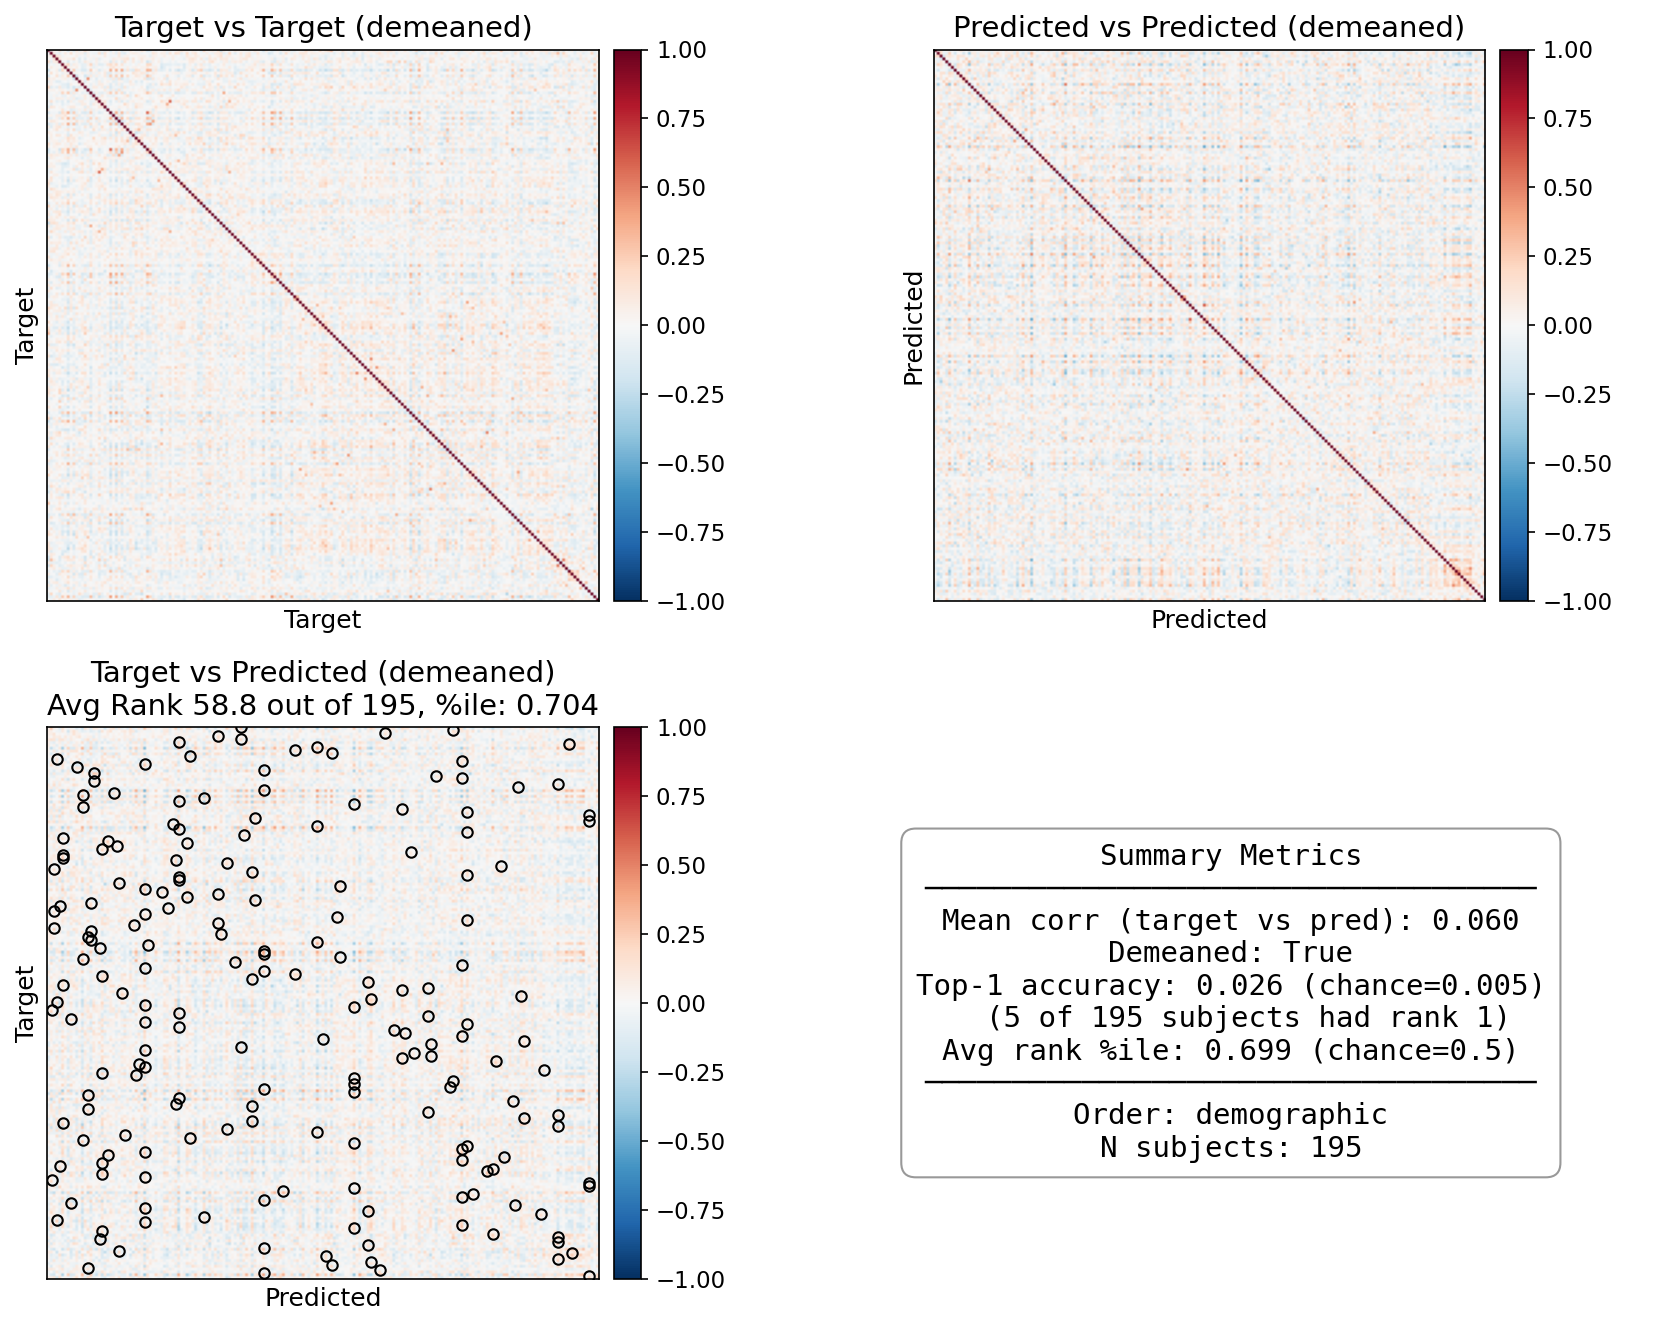

returned noise_preds [[ 0.10335524  0.27345097  0.79338528 ...  0.07845213  0.10779611
   0.357242  ]
 [ 0.19199795  0.47149244  0.6724817  ... -0.13729254 -0.09331816
   0.66529671]
 [ 0.3631452   0.63926439  0.88444674 ... -0.01370379  0.12942167
   0.399605  ]
 ...
 [-0.0823811   0.82869695  1.07752755 ... -0.06908565 -0.0044076
   0.4032794 ]
 [ 0.12395494  0.68586341  0.6269889  ... -0.12566296  0.16673283
   0.53747603]
 [ 0.05569954  0.62698798  0.69579933 ... -0.09271123  0.09947311
   0.36341408]]


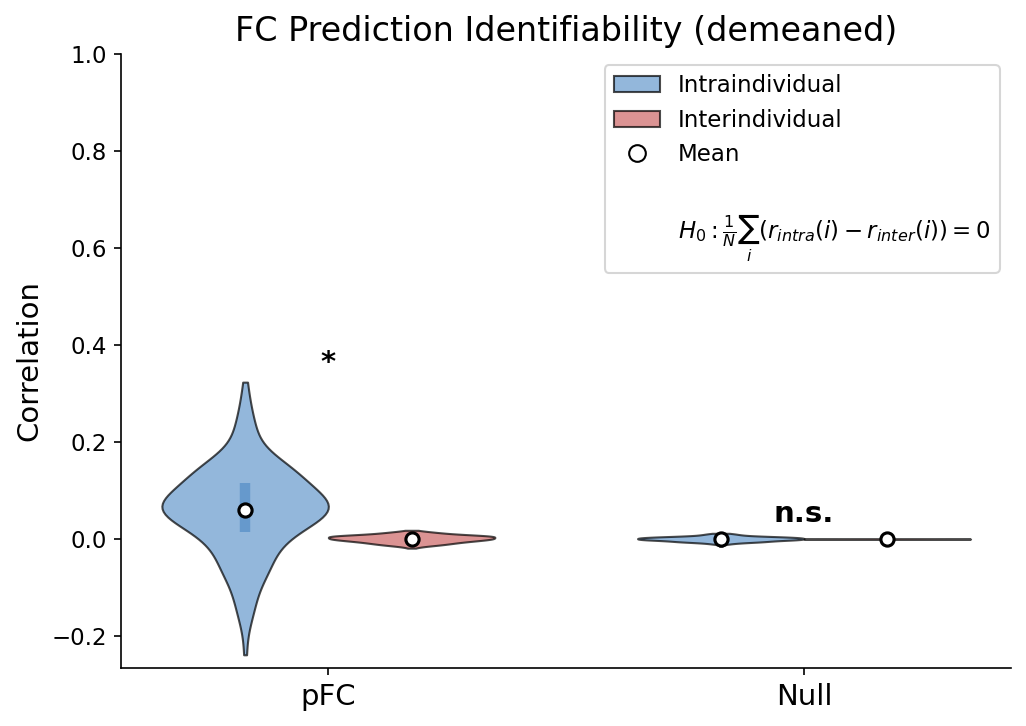


Identifiability Summary:
Condition    r_intra    r_inter    d          t          p            Cohen d   
----------------------------------------------------------------------
pFC          0.0603     0.0008     0.0595     9.02       1.80e-16     0.65      
Null         0.0004     -0.0001    0.0005     1.35       1.78e-01     0.10      


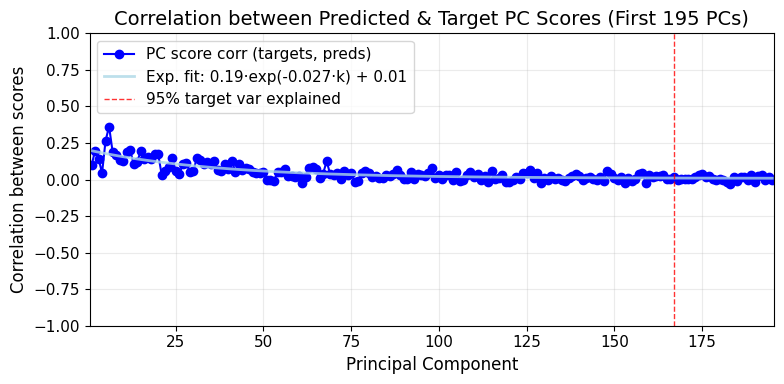

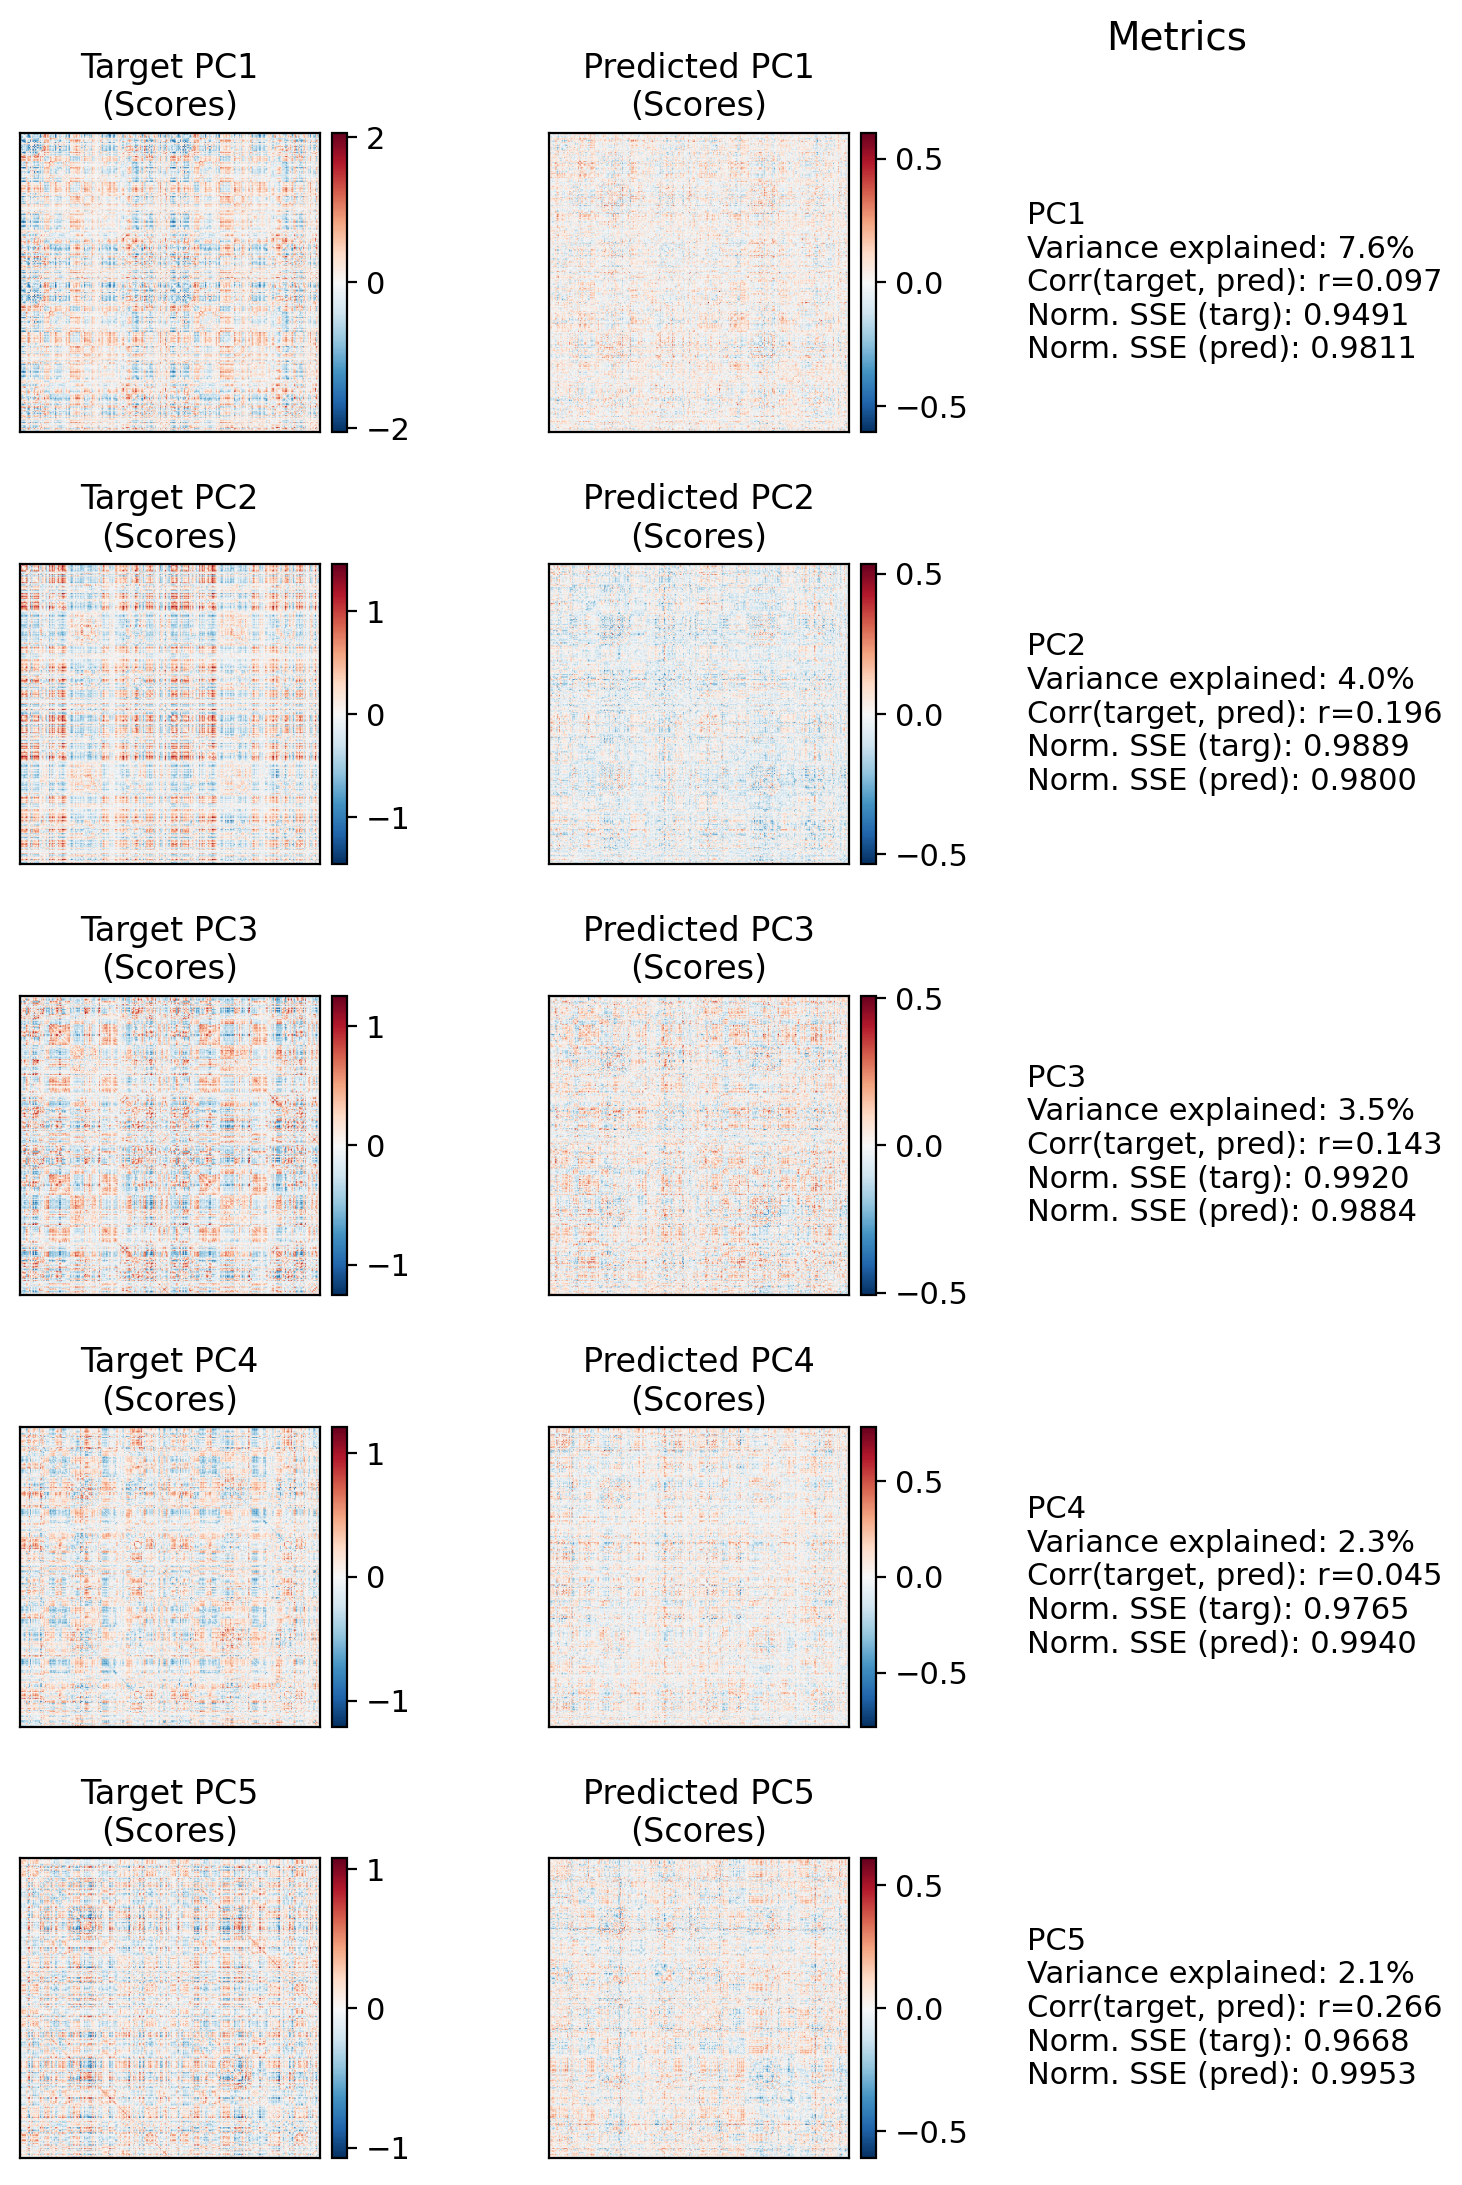

{'mse': np.float32(0.02027777),
 'r2': np.float32(-0.5574016),
 'pearson': np.float32(0.7607147),
 'demeaned_pearson': np.float64(0.06031198499866747),
 'avg_rank': np.float64(0.6505193951347799),
 'top1_acc': np.float64(0.03076923076923077)}

In [25]:
config_override = {
    "model": {
        "fit_domain": "raw_edges",
        "n_components_pca": 128,  # used for PCA-projected diagnostics / uncertainty summaries
        "lambda_ridge": 1e-2,
        "covariance_estimator": "empirical", # raw_edges currently supports empirical only
        "zscore_pca_scores": False,
        "use_covariates": False,
        "cov_sources": ["age", "sex", "fs_volumes"],  # used only when use_covariates=True
    }
}

run_out = sim.run_single(
    mode="dev",
    save_checkpoint=False,
    config_override=config_override,
    run_eval=True,
)

run_out["test_metrics"]["base_metrics"]


In [26]:
model = run_out["model"]
diag = model.get_diagnostics()

summary = {
    "fit_domain": diag["fit_domain"],
    "n_components_pca": model.n_components_pca,
    "lambda_ridge": model.lambda_ridge,
    "feature_dim": diag["feature_dim"],
    "n_train": diag["n_train"],
    "use_covariates": diag["use_covariates"],
    "cov_sources": diag["cov_sources"],
    "covariate_dim": diag["covariate_dim"],
    "condition_number": diag["condition_number"],
}
summary


{'fit_domain': 'raw_edges',
 'n_components_pca': 128,
 'lambda_ridge': 0.01,
 'feature_dim': 64620,
 'n_train': 683,
 'condition_number': 919331.0269446953}

In [27]:
def _to_np(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def plot_heatmap(ax, arr, title, cmap="coolwarm", center=None):
    arr = _to_np(arr)
    if center is None:
        im = ax.imshow(arr, aspect="auto", interpolation="nearest", cmap=cmap)
    else:
        bound = np.max(np.abs(arr))
        im = ax.imshow(arr, aspect="auto", interpolation="nearest", cmap=cmap, vmin=-bound, vmax=bound)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

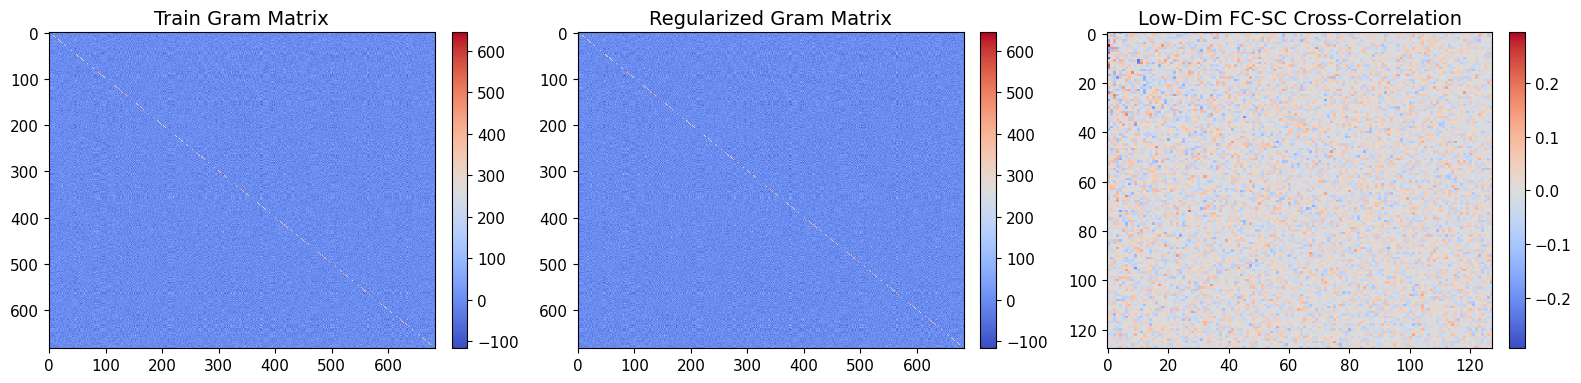

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_heatmap(axes[0], diag["gram_train"], "Train Gram Matrix")
plot_heatmap(axes[1], diag["gram_train_reg"], "Regularized Gram Matrix")
plot_heatmap(axes[2], diag["cross_correlation"], "Low-Dim FC-SC Cross-Correlation", center=0.0)
plt.tight_layout()
plt.show()

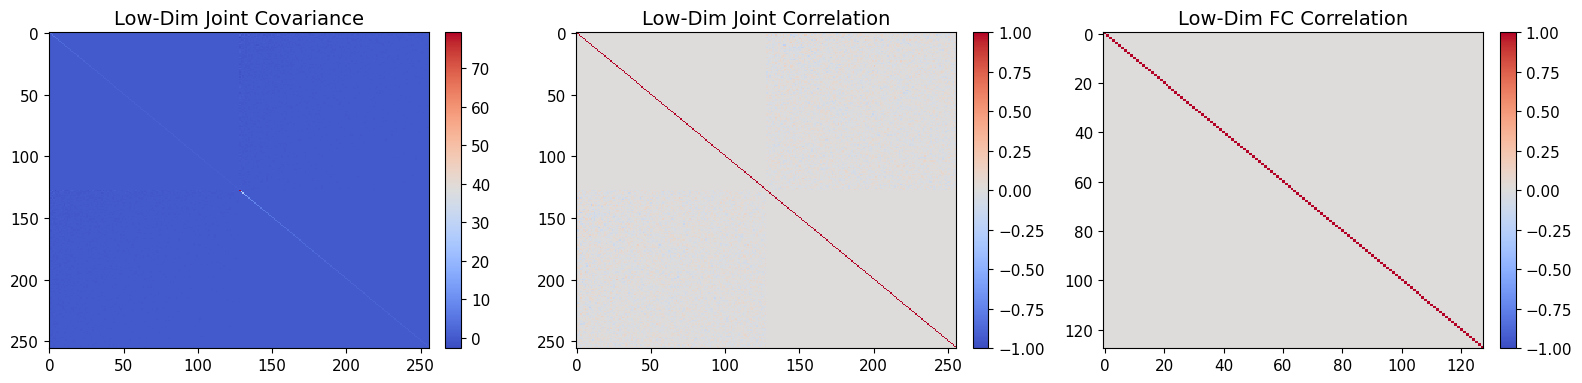

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_heatmap(axes[0], diag["Sigma_joint"], "Low-Dim Joint Covariance")
plot_heatmap(axes[1], diag["joint_correlation"], "Low-Dim Joint Correlation", center=0.0)
plot_heatmap(axes[2], diag["target_correlation"], "Low-Dim FC Correlation", center=0.0)
plt.tight_layout()
plt.show()

Estimate uncertainty from the model residuals

In [14]:
residual_std_edges = _to_np(diag["residual_std_edges"])
edge_df = pd.DataFrame({
    "edge": np.arange(len(residual_std_edges)),
    "residual_std": residual_std_edges,
}).sort_values("residual_std", ascending=False)

edge_df.head(15)

,edge,residual_std
63846,63846,0.000020
27853,27853,0.000020
26947,26947,0.000019
25002,25002,0.000019
42214,42214,0.000019
50391,50391,0.000019
26398,26398,0.000019
22726,22726,0.000019
27940,27940,0.000019
44188,44188,0.000019


In [15]:
target_pca_residual_std = _to_np(diag["target_pca_residual_std"])
target_pca_target_std = _to_np(diag["target_pca_target_std"])
uncertainty_ratio = _to_np(diag["target_pca_uncertainty_ratio"])
explained_fraction = _to_np(diag["target_pca_explained_fraction"])

# Residual std here is the remaining unexplained target variation after fitting the raw-edge model,
# projected into the target PCA basis for easier interpretation.
uncertainty_df = pd.DataFrame({
    "component": np.arange(len(target_pca_residual_std)),
    "residual_std": target_pca_residual_std,
    "target_marginal_std": target_pca_target_std,
    "uncertainty_ratio": uncertainty_ratio,
    "explained_fraction": explained_fraction,
}).sort_values("residual_std", ascending=False)

uncertainty_df.head(15)

,component,residual_std,target_marginal_std,uncertainty_ratio,explained_fraction
0,0,0.000704,8.903588,0.000079,1.0
1,1,0.000466,5.676703,0.000082,1.0
2,2,0.000433,5.034922,0.000086,1.0
3,3,0.000339,4.243513,0.000080,1.0
4,4,0.000301,3.739341,0.000080,1.0
5,5,0.000269,3.369624,0.000080,1.0
9,9,0.000252,2.979039,0.000085,1.0
7,7,0.000237,3.061819,0.000077,1.0
8,8,0.000232,3.021159,0.000077,1.0
6,6,0.000227,3.232124,0.000070,1.0


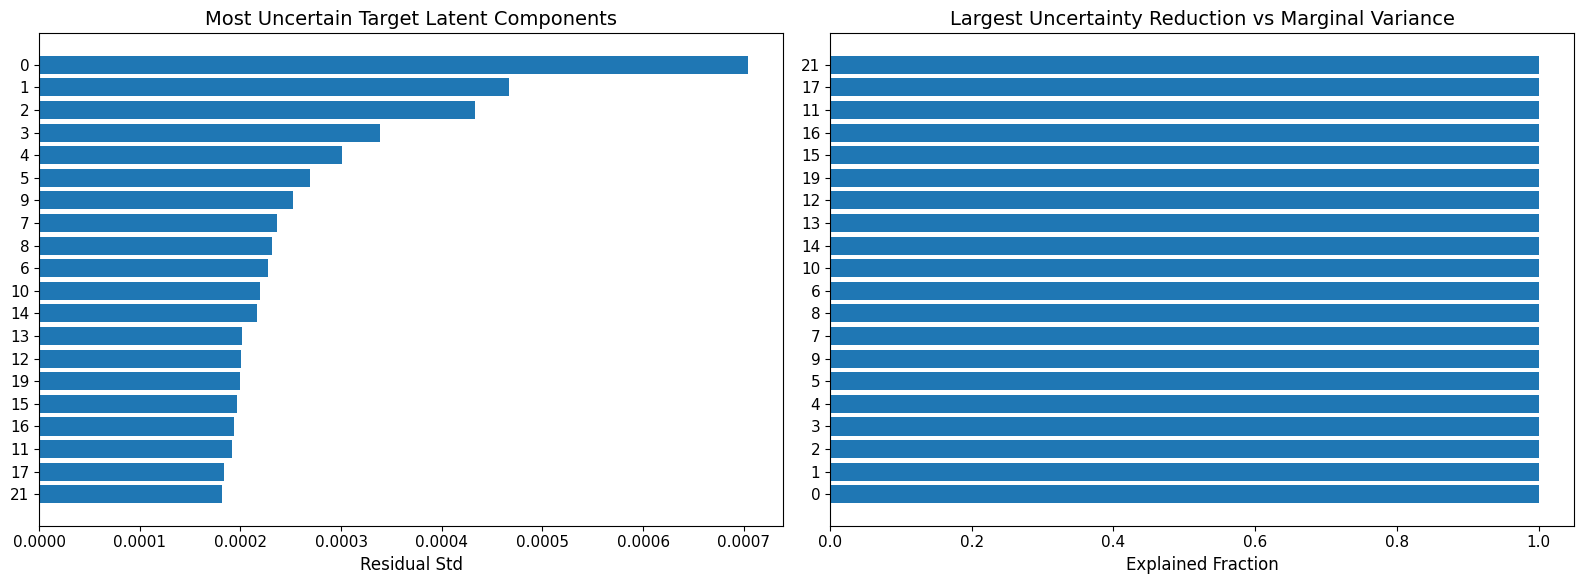

In [16]:
top_n = 20
most_uncertain = uncertainty_df.head(top_n).sort_values("residual_std")
most_reduced = uncertainty_df.sort_values("explained_fraction", ascending=False).head(top_n).sort_values("explained_fraction")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(most_uncertain["component"].astype(str), most_uncertain["residual_std"])
axes[0].set_title("Most Uncertain Target Latent Components")
axes[0].set_xlabel("Residual Std")

axes[1].barh(most_reduced["component"].astype(str), most_reduced["explained_fraction"])
axes[1].set_title("Largest Uncertainty Reduction vs Marginal Variance")
axes[1].set_xlabel("Explained Fraction")

plt.tight_layout()
plt.show()

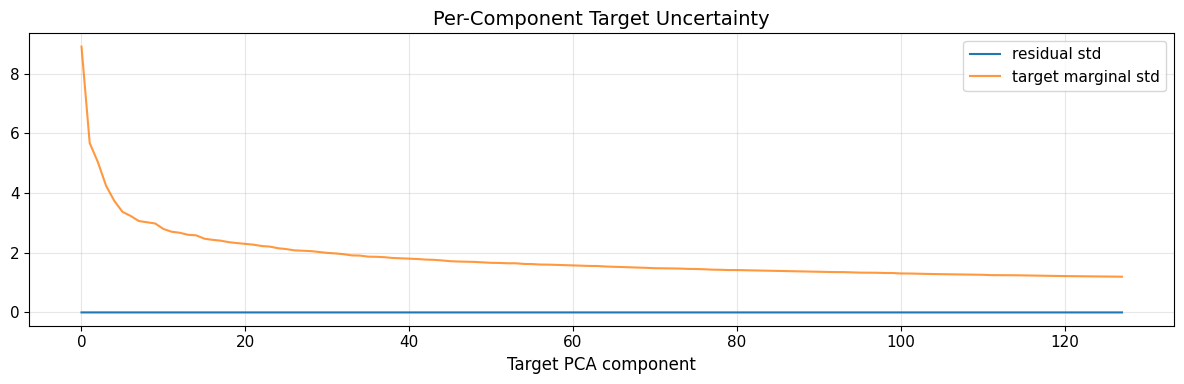

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(target_pca_residual_std, label="residual std")
ax.plot(target_pca_target_std, label="target marginal std", alpha=0.8)
ax.set_title("Per-Component Target Uncertainty")
ax.set_xlabel("Target PCA component")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
print("Average edge residual std:", float(residual_std_edges.mean()))
print("Average target-PCA residual std:", float(target_pca_residual_std.mean()))
print("Average uncertainty ratio:", float(uncertainty_ratio.mean()))

Average edge residual std: 9.492494427831843e-06
Average target-PCA residual std: 0.00014778257173020393
Average uncertainty ratio: 8.101392450043932e-05
